In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv("customer_data.csv")
df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [ ]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Handle missing values
df['churn_flag'] = df['churn_flag'].fillna(False)

# Remove duplicates
df = df.drop_duplicates()

In [ ]:
# Customer Lifetime (in days)
# Original code tried to use 'End Date' and 'Start Date' which are not in the DataFrame.
# Using 'signup_date' as the start date. Since 'End Date' is not available,
# calculating lifetime as duration from signup to today.
df['Lifetime'] = (pd.to_datetime("today") - df['signup_date']).dt.days

# The original code's fillna logic is now incorporated directly by calculating
# lifetime up to today for all customers, as there's no explicit 'End Date'.

# Monthly Revenue
# Original code tried to use 'Monthly Charges' which is not in the DataFrame.
# This part cannot be fixed without more information on how to calculate revenue.
# Commenting it out for now.
# df['Revenue'] = df['Monthly Charges']

In [ ]:
churn_rate = df['churn_flag'].value_counts(normalize=True) * 100
print(churn_rate)

churn_flag
False    78.0
True     22.0
Name: proportion, dtype: float64


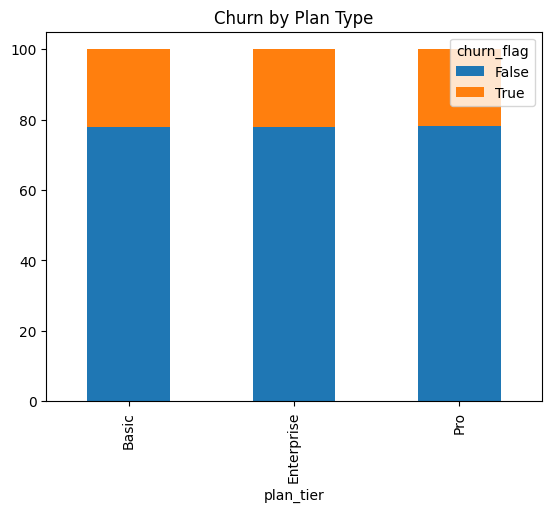

In [ ]:
plan_churn = pd.crosstab(df['plan_tier'], df['churn_flag'], normalize='index') * 100

plan_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Plan Type")
plt.show()

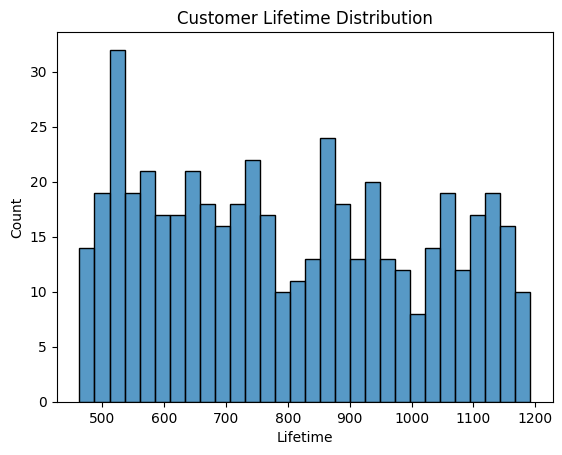

In [ ]:
sns.histplot(df['Lifetime'], bins=30)
plt.title("Customer Lifetime Distribution")
plt.show()

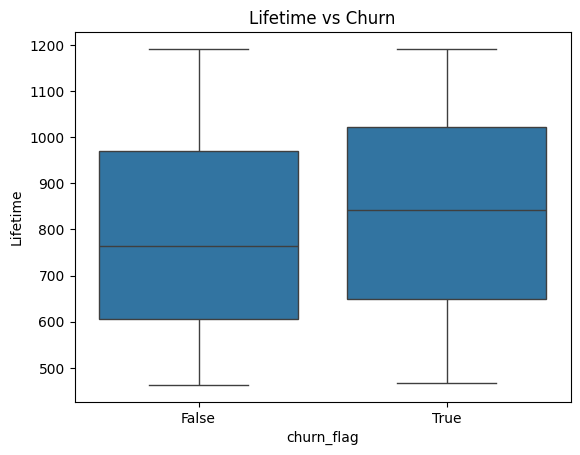

In [ ]:
sns.boxplot(data=df, x='churn_flag', y='Lifetime')
plt.title("Lifetime vs Churn")
plt.show()

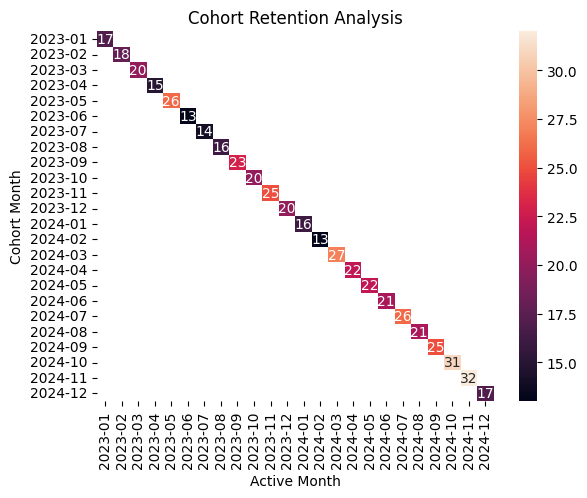

In [ ]:
df['Cohort Month'] = df['signup_date'].dt.to_period('M')
df['Active Month'] = df['signup_date'].dt.to_period('M')

cohort = df.groupby(['Cohort Month', 'Active Month']).agg({'account_id':'nunique'}).reset_index()

cohort_pivot = cohort.pivot(index='Cohort Month', columns='Active Month', values='account_id')

sns.heatmap(cohort_pivot, annot=True, fmt='.0f')
plt.title("Cohort Retention Analysis")
plt.show()

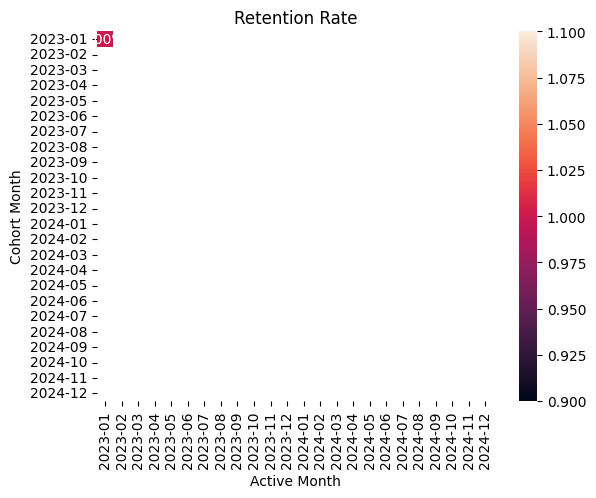

In [ ]:
retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)
sns.heatmap(retention, annot=True, fmt=".0%")
plt.title("Retention Rate")
plt.show()

In [ ]:
total_customers = df['account_id'].nunique()
avg_lifetime = df['Lifetime'].mean()
# avg_revenue = df['Revenue'].mean()

print("Total Customers:", total_customers)
print("Average Lifetime:", avg_lifetime)
# print("Average Monthly Revenue:", avg_revenue)

Total Customers: 500
Average Lifetime: 801.726


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=79cfb14c98e6930bcd185b4ddd5594de7d4232186cc063df74503b6ac202a708
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


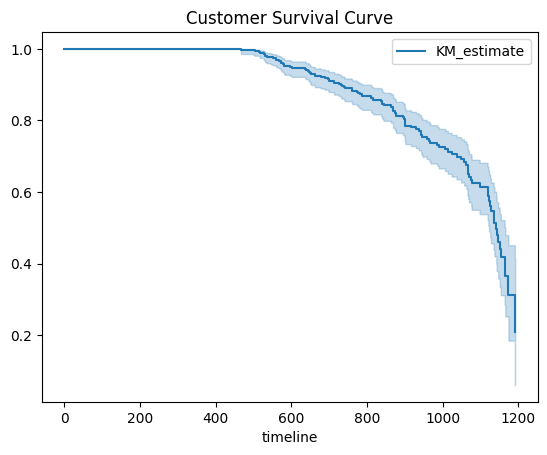

In [ ]:
!pip install lifelines
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df['Lifetime'], event_observed=df['churn_flag'])
kmf.plot()
plt.title("Customer Survival Curve")
plt.show()